In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:09<00:00, 11.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import random

### Dataset Exploration

The dataset is located at `/kaggle/input/brian-tumor-dataset`. Let's first check the class distribution.

Class Distribution:
         Class  Count
0  Brain Tumor   2513
1      Healthy   2087


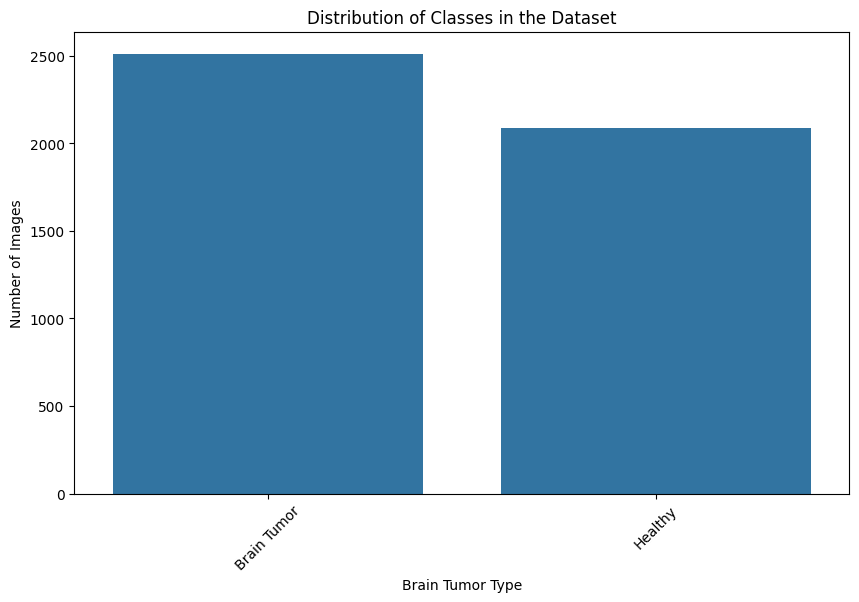

In [3]:
# Assuming data_root_path is defined from previous steps
if 'data_root_path' not in locals():
    data_root_path = os.path.join(path, 'Brain Tumor Data Set', 'Brain Tumor Data Set')

class_names = os.listdir(data_root_path)
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(data_root_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame for easier plotting
df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

print("Class Distribution:")
print(df_class_counts)

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df_class_counts)
plt.title('Distribution of Classes in the Dataset')
plt.xlabel('Brain Tumor Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

Now, let's analyze the image sizes within the dataset.

Image Size Statistics per Class:

Class: Brain Tumor
  Min Width: 175, Max Width: 1275, Avg Width: 402.87
  Min Height: 167, Max Height: 1427, Avg Height: 432.99

Class: Healthy
  Min Width: 150, Max Width: 1920, Avg Width: 307.25
  Min Height: 168, Max Height: 1446, Avg Height: 313.26


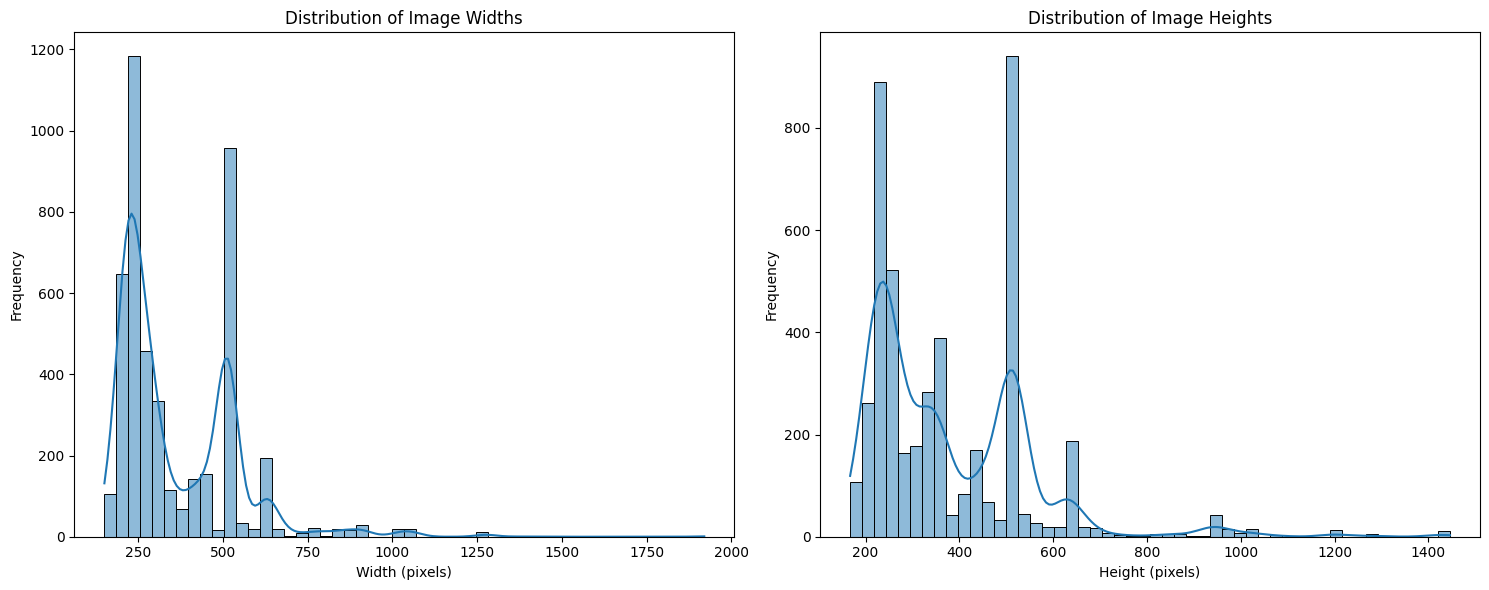

In [4]:
image_sizes = defaultdict(list)

for class_name in class_names:
    class_path = os.path.join(data_root_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    height, width, channels = img.shape
                    image_sizes[class_name].append({'width': width, 'height': height, 'channels': channels})
            except Exception as e:
                print(f"Could not read image {img_path}: {e}")

# Analyze image sizes
all_widths = []
all_heights = []

print("Image Size Statistics per Class:")
for class_name, sizes in image_sizes.items():
    widths = [s['width'] for s in sizes]
    heights = [s['height'] for s in sizes]

    print(f"\nClass: {class_name}")
    print(f"  Min Width: {np.min(widths)}, Max Width: {np.max(widths)}, Avg Width: {np.mean(widths):.2f}")
    print(f"  Min Height: {np.min(heights)}, Max Height: {np.max(heights)}, Avg Height: {np.mean(heights):.2f}")

    all_widths.extend(widths)
    all_heights.extend(heights)

# Plot distribution of image widths and heights
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(all_widths, bins=50, kde=True)
plt.title('Distribution of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(all_heights, bins=50, kde=True)
plt.title('Distribution of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Finally, let's visualize some sample images from each class.

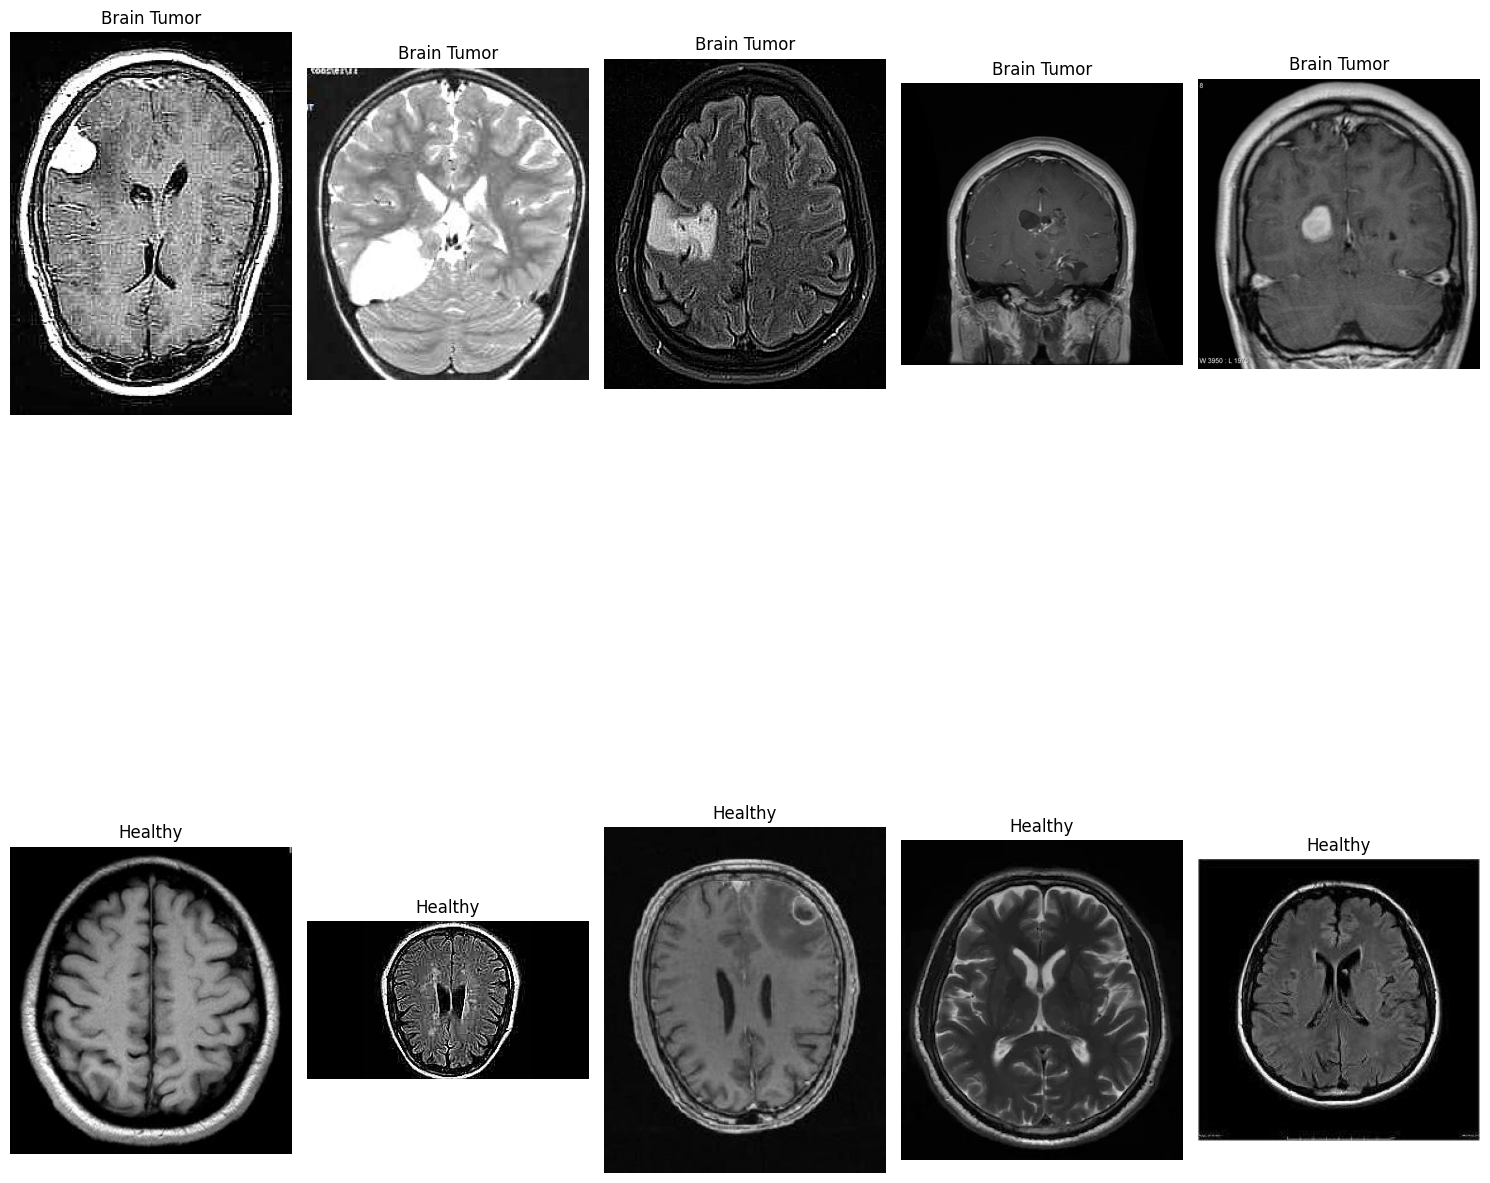

In [6]:
num_samples_per_class = 5  # Number of samples to display per class

plt.figure(figsize=(15, 20)) # Adjust figure size for more samples
plot_idx = 1

for class_name in class_names:
    class_path = os.path.join(data_root_path, class_name)
    if os.path.isdir(class_path):
        images_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Select random samples
        selected_images = random.sample(images_in_class, min(len(images_in_class), num_samples_per_class))

        for img_name in selected_images:
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib

                plt.subplot(len(class_names), num_samples_per_class, plot_idx)
                plt.imshow(img)
                plt.title(f"{class_name}")
                plt.axis('off')
                plot_idx += 1
            except Exception as e:
                print(f"Could not display image {img_path}: {e}")

plt.tight_layout()
plt.show()